[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/notebooks/EN/chapter10_lecture_notebook.ipynb)

# Statistics of Financial Markets — Chapter 10: VaR, ES and backtesting

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- VaR 1% and ES 2.5% of daily returns: definitions, the S&P 500 since 2000.
- Five unconditional methods: historical simulation, Normal, Student-t, Cornish–Fisher, EVT (VaRest, SFEVaRqqplot).
- Conditional VaR: GARCH(1,1)-t and filtered historical simulation; rolling forecasts since 2005 (SFEVaRtimeplot, SFEVaRbank).
- Backtesting: Kupiec, Christoffersen, the Basel traffic light, the Acerbi–Székely test of ES (SFEvar_pot_backtesting).
- Portfolio VaR for the BET and the S&P 500: variance–covariance, tail dependence, Gaussian and t copulas.
- References: Franke, Härdle and Hafner (2019), *Statistics of Financial Markets*, 5th ed., Ch. 16–18; McNeil, Frey and Embrechts (2015), *Quantitative Risk Management*, Ch. 2 and 7; Artzner et al. (1999); Kupiec (1995); Christoffersen (1998).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_10'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/SFM - Statistica pietelor financiare/2026/notebooks/EN


In [2]:
# the arch package (maximum-likelihood estimation of GARCH models) is not part of Google Colab
!pip install -q arch

In [3]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [4]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [5]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Definitions used in the whole notebook

- Daily log returns $r_t = 100(\ln P_t - \ln P_{t-1})$ in %; S&P 500, DAX and BET since 2000, Bitcoin since 2014, Banca Transilvania and OMV Petrom since 2010 (Banca Transilvania without 30–31 May 2016, a data error).
- Level $\alpha$ = the probability of the tail. $\mathrm{VaR}_\alpha = -q_\alpha$: the loss exceeded with probability $\alpha$ (VaR 1%); $\mathrm{ES}_\alpha$: the average loss on the worst $\alpha$ of days (ES 2.5%). Both are positive numbers (losses).
- Historical simulation: $k = \lceil n\alpha \rceil$, VaR $= -r_{(k)}$, ES $= -$ the mean of the $k$ smallest returns.

In [6]:
from arch import arch_model
NAME = {'sp500': 'S&P 500', 'dax': 'DAX', 'bet': 'BET', 'btc': 'Bitcoin', 'tlv': 'Banca Transilvania', 'snp': 'OMV Petrom', 'brd': 'BRD'}
START = {'sp500': '2000-01-01', 'dax': '2000-01-01', 'bet': '2000-01-01', 'btc': None, 'tlv': '2010-01-01', 'snp': '2010-01-01', 'brd': '2010-01-01'}
ASSETS = ['sp500', 'dax', 'bet', 'btc', 'tlv', 'snp']
BT_ASSETS = ['sp500', 'dax', 'bet', 'btc']
BAD_DAYS = {'tlv': ['2016-05-30', '2016-05-31']}
COLORS = {'sp500': '#1A3A6E', 'dax': '#17A2B8', 'bet': '#CD0000', 'btc': '#B5853F', 'tlv': '#E67E22', 'snp': '#2E7D32'}
EPISODES = {'2008': ('2008-09-01', '2009-03-31'), '2020': ('2020-02-15', '2020-05-31')}
ALPHA_VAR = 0.01
ALPHA_ES = 0.025
WINDOW = 500
REFIT = 250
OOS_START = {'sp500': '2005-01-01', 'dax': '2005-01-01', 'bet': '2005-01-01', 'btc': '2017-01-01'}
POT_Q = 0.9
METHODS = ['HS', 'Normal', 'GARCH-t', 'FHS']
MCOL = {'HS': '#B5853F', 'Normal': '#2E7D32', 'GARCH-t': '#CD0000', 'FHS': '#1A3A6E'}
PORT = ('bet', 'sp500')
WEIGHTS = (0.5, 0.5)
N_SIM = 200000
N_Z2 = 1000
SEED = 2026
PLUS = {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.4, 6: 0.5, 7: 0.65, 8: 0.75, 9: 0.85}


def returns(k, start=None, end=None):
    """Daily log returns in % on the series' own calendar; known data errors removed."""
    r = log_returns(k, start or START.get(k)) if end is None else log_returns(k, start or START.get(k), end)
    if k in BAD_DAYS:
        r = r.drop(pd.to_datetime(BAD_DAYS[k]), errors='ignore')
    return r


def hs_var(x, a=ALPHA_VAR):
    """Historical simulation: VaR_a = -r_(k), the k-th smallest return, k = ceil(n a)."""
    xs = np.sort(np.asarray(x, float))
    k = int(np.ceil(len(xs) * a - 1e-9))
    return float(-xs[k - 1])


def hs_es(x, a=ALPHA_ES):
    """Historical simulation: ES_a = minus the average of the k smallest returns, k = ceil(n a)."""
    xs = np.sort(np.asarray(x, float))
    k = int(np.ceil(len(xs) * a - 1e-9))
    return float(-xs[:k].mean())


def normal_var(mu, sd, a=ALPHA_VAR):
    """VaR_a = -(mu + sd z_a), z_a the a-quantile of N(0, 1) (negative)."""
    return float(-(mu + sd * stats.norm.ppf(a)))


def normal_es(mu, sd, a=ALPHA_ES):
    """ES_a = -mu + sd phi(z_a) / a."""
    return float(-mu + sd * stats.norm.pdf(stats.norm.ppf(a)) / a)


def t_es_factor(nu, a=ALPHA_ES):
    """ES of a Student-t variable with nu degrees of freedom (scale 1): f(t_a) (nu + t_a^2) / ((nu - 1) a)."""
    q = stats.t.ppf(a, nu)
    return float(stats.t.pdf(q, nu) * (nu + q ** 2) / ((nu - 1) * a))


def std_t_q(nu, a=ALPHA_VAR):
    """a-quantile of the standardised Student-t (variance 1): t_nu^{-1}(a) sqrt((nu - 2)/nu)."""
    return float(stats.t.ppf(a, nu) * np.sqrt((nu - 2) / nu))


def std_t_es(nu, a=ALPHA_ES):
    """ES_a of the standardised Student-t (variance 1)."""
    return float(np.sqrt((nu - 2) / nu) * t_es_factor(nu, a))


def t_fit(x):
    """Student-t with location m, scale s and nu degrees of freedom, fitted by maximum likelihood (scipy)."""
    nu, m, s = stats.t.fit(np.asarray(x, float))
    return float(nu), float(m), float(s)


def t_var_es(x, a_var=ALPHA_VAR, a_es=ALPHA_ES):
    nu, m, s = t_fit(x)
    return {'var': float(-(m + s * stats.t.ppf(a_var, nu))), 'es': float(-m + s * t_es_factor(nu, a_es)),
            'nu': nu, 'm': m, 's': s}


def cf_z(a, S, K):
    """Cornish-Fisher quantile of a standardised variable with skewness S and excess kurtosis K."""
    z = stats.norm.ppf(a)
    return z + (z ** 2 - 1) * S / 6 + (z ** 3 - 3 * z) * K / 24 - (2 * z ** 3 - 5 * z) * S ** 2 / 36


def cf_var_es(x, a_var=ALPHA_VAR, a_es=ALPHA_ES):
    """Cornish-Fisher VaR = -(mu + sd z_cf); ES = minus the average of the CF quantiles on (0, a_es)."""
    x = np.asarray(x, float)
    mu, sd = x.mean(), x.std(ddof=1)
    S, K = float(stats.skew(x)), float(stats.kurtosis(x))
    u = (np.arange(2000) + 0.5) / 2000 * a_es
    return {'var': float(-(mu + sd * cf_z(a_var, S, K))), 'es': float(-(mu + sd * cf_z(u, S, K).mean())),
            'z': float(cf_z(a_var, S, K)), 'S': S, 'K': K, 'mu': float(mu), 'sd': float(sd)}


def pot_fit(x, q=POT_Q):
    """GPD fit to the losses L = -r above the threshold u = q-quantile of the losses (peaks over threshold)."""
    L = -np.asarray(x, float)
    u = float(np.quantile(L, q))
    exc = L[L > u] - u
    xi, _, beta = stats.genpareto.fit(exc, floc=0)
    return {'u': u, 'xi': float(xi), 'beta': float(beta), 'Nu': int(len(exc)), 'n': int(len(L))}


def pot_var(f, a):
    """VaR_a = u + beta/xi [(n a / N_u)^(-xi) - 1], valid for a < N_u / n."""
    return float(f['u'] + f['beta'] / f['xi'] * ((f['n'] * a / f['Nu']) ** (-f['xi']) - 1))


def pot_es(f, a):
    """ES_a = VaR_a / (1 - xi) + (beta - xi u) / (1 - xi), valid for xi < 1."""
    return float(pot_var(f, a) / (1 - f['xi']) + (f['beta'] - f['xi'] * f['u']) / (1 - f['xi']))


def garch_fit(r, last_obs=None):
    """GARCH(1,1) with constant mean and standardised Student-t innovations (arch package)."""
    am = arch_model(r, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
    return am.fit(disp='off', last_obs=last_obs, options={'maxiter': 2000})

## 1. VaR 1% and ES 2.5% of the S&P 500

- Histogram of daily returns with minus VaR 1% and minus ES 2.5%.

In [7]:
def fig_var_es_def(k='sp500', save=True):
    """Histogram of daily returns with minus VaR 1% and minus ES 2.5% (historical simulation)."""
    x = returns(k)
    v1, q25, e25 = hs_var(x, ALPHA_VAR), -hs_var(x, ALPHA_ES), hs_es(x, ALPHA_ES)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    bins = np.arange(-13, 12.01, 0.25)
    ax.hist(x, bins=bins, density=True, color=st.MainBlue, alpha=0.75, label=f'daily log returns of the {NAME[k]} (%)')
    ax.axvspan(-13, q25, color=st.IDAred, alpha=0.08, label='worst 2.5% of the days')
    ax.axvline(-v1, color=st.IDAred, lw=2, label=f'minus VaR 1% = {-v1:.2f}%')
    ax.axvline(-e25, color=st.Purple, lw=2, ls='--', label=f'minus ES 2.5% = {-e25:.2f}%')
    ax.set_xlim(-13, 12)
    ax.set_xlabel('daily return (%)')
    ax.set_ylabel('density')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch10_var_es_def')
    return {'var1': v1, 'q25': q25, 'es25': e25, 'n': int(len(x)), 'n_tail1': int((x < -v1).sum()),
            'min': float(x.min()), 'date_min': x.idxmin().date().isoformat()}

{'var1': 3.455209453263386,
 'q25': -2.5107730975783227,
 'es25': 3.7613189281197386,
 'n': 6714,
 'n_tail1': 67,
 'min': -12.76521830653392,
 'date_min': '2020-03-16'}

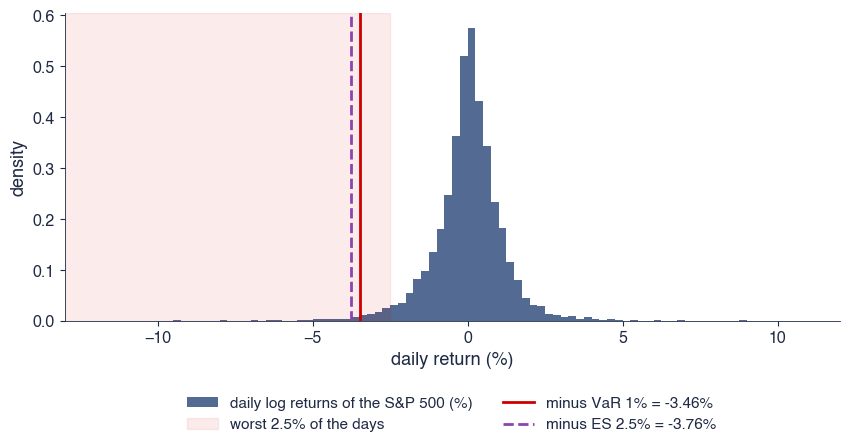

In [8]:
fig_var_es_def(save=False)

## 2. Five unconditional methods on six series

- Historical simulation, Normal, Student-t (maximum likelihood), Cornish–Fisher, EVT (GPD above the 90% quantile of the losses); GARCH-t and FHS for the next day.

In [9]:
def conditional_next_day(k, a_var=ALPHA_VAR, a_es=ALPHA_ES):
    """VaR and ES for the day after the last observation: GARCH(1,1)-t and filtered historical simulation."""
    r = returns(k)
    res = garch_fit(r)
    p = res.params
    mu, nu = float(p['mu']), float(p['nu'])
    s_next = float(np.sqrt(res.forecast(horizon=1, reindex=False).variance.values[-1, 0]))
    z = res.std_resid.dropna().values
    return {'mu': mu, 'nu': nu, 'omega': float(p['omega']), 'alpha': float(p['alpha[1]']), 'beta': float(p['beta[1]']),
            'sigma': s_next, 'q_t': std_t_q(nu, a_var), 'es_t': std_t_es(nu, a_es),
            'var_g': float(-(mu + s_next * std_t_q(nu, a_var))), 'es_g': float(-mu + s_next * std_t_es(nu, a_es)),
            'q_z': float(-hs_var(z, a_var)), 'es_z': hs_es(z, a_es),
            'var_f': float(-(mu + s_next * -hs_var(z, a_var))), 'es_f': float(-mu + s_next * hs_es(z, a_es)),
            'n': int(len(r)), 'last': r.index[-1].date().isoformat(), 'r_last': float(r.iloc[-1])}


def methods_table(assets=ASSETS):
    """VaR 1% and ES 2.5% (in %) of each series on its whole sample by five unconditional methods, plus the
    conditional GARCH-t and FHS values for the next day."""
    out = {}
    for k in assets:
        x = returns(k)
        mu, sd = float(x.mean()), float(x.std())
        tt = t_var_es(x)
        cf = cf_var_es(x)
        f = pot_fit(x)
        c = conditional_next_day(k)
        out[k] = {'n': int(len(x)), 'first': x.index[0].date().isoformat(), 'mu': mu, 'sd': sd,
                  'skew': cf['S'], 'exkurt': cf['K'], 'nu': tt['nu'], 'xi': f['xi'],
                  'HS': {'var': hs_var(x), 'es': hs_es(x)},
                  'Normal': {'var': normal_var(mu, sd), 'es': normal_es(mu, sd)},
                  'Student-t': {'var': tt['var'], 'es': tt['es']},
                  'Cornish-Fisher': {'var': cf['var'], 'es': cf['es']},
                  'EVT': {'var': pot_var(f, ALPHA_VAR), 'es': pot_es(f, ALPHA_ES)},
                  'GARCH-t': {'var': c['var_g'], 'es': c['es_g']}, 'FHS': {'var': c['var_f'], 'es': c['es_f']},
                  'pot': f, 'cf_z': cf['z'], 't': tt, 'cond': c}
    return out

In [10]:
MT = methods_table()
pd.DataFrame({(NAME[k], m): {'VaR 1%': MT[k][m]['var'], 'ES 2.5%': MT[k][m]['es']} for k in ASSETS for m in ['HS', 'Normal', 'Student-t', 'Cornish-Fisher', 'EVT', 'GARCH-t', 'FHS']}).T.round(2)

VaR 1%  ES 2.5%
S&P 500            HS                3.46     3.76
                   Normal            2.80     2.81
                   Student-t         3.46     3.95
                   Cornish-Fisher    6.08     6.65
                   EVT               3.56     3.77
                   GARCH-t           1.75     1.81
                   FHS               1.91     2.03
DAX                HS                4.20     4.26
                   Normal            3.26     3.27
                   Student-t         3.96     4.37
                   Cornish-Fisher    5.42     5.81
                   EVT               4.05     4.24
                   GARCH-t           2.31     2.38
                   FHS               2.48     2.55
BET                HS                4.14     4.57
                   Normal            3.19     3.21
                   Student-t         4.06     4.76
                   Cornish-Fisher    7.25     7.93
                   EVT               4.19     4.57
                   GARCH-t           4.51     4.72
                   FHS               4.81     5.04
Bitcoin            HS               10.54    10.84
                   Normal            7.99     8.03
                   Student-t        11.06    13.37
                   Cornish-Fisher   18.89    20.69
                   EVT              10.38    10.90
                   GARCH-t           7.37     8.11
                   FHS               7.99     8.57
Banca Transilvania HS                5.11     5.37
                   Normal            4.01     4.03
                   Student-t         4.63     5.03
                   Cornish-Fisher   10.19    11.20
                   EVT               4.90     5.35
                   GARCH-t           7.18     7.53
                   FHS               7.33     8.00
OMV Petrom         HS                4.29     4.70
                   Normal            3.70     3.72
                   Student-t         4.26     4.57
                   Cornish-Fisher    7.55     8.18
                   EVT               4.38     4.71
                   GARCH-t           5.06     5.31
                   FHS               5.39     5.65

## 3. VaR across tail probabilities, precision and horizon

- $\mathrm{VaR}_\alpha$ for $\alpha$ from 5% to 0.1%; bootstrap intervals of the historical VaR and ES; the square-root-of-time rule.

In [11]:
def var_curve(x, alphas):
    """VaR_alpha (positive, in %) for each tail probability by five unconditional methods."""
    mu, sd = float(np.mean(x)), float(np.std(x, ddof=1))
    tt = t_var_es(x)
    cf = cf_var_es(x)
    f = pot_fit(x)
    out = {'historical': [hs_var(x, a) for a in alphas], 'Normal': [normal_var(mu, sd, a) for a in alphas],
           'Student-t': [float(-(tt['m'] + tt['s'] * stats.t.ppf(a, tt['nu']))) for a in alphas],
           'Cornish-Fisher': [float(-(mu + sd * cf_z(a, cf['S'], cf['K']))) for a in alphas],
           'EVT (POT)': [pot_var(f, a) if a < f['Nu'] / f['n'] else np.nan for a in alphas]}
    return out


def fig_var_curves(keys=('sp500', 'bet'), save=True):
    """VaR as a function of the tail probability alpha (log axis) for the S&P 500 and the BET."""
    alphas = np.array([0.001, 0.002, 0.003, 0.005, 0.0075, 0.01, 0.015, 0.02, 0.025, 0.03, 0.04, 0.05])
    sty = {'historical': (st.DarkText, 'o', '-'), 'Normal': (st.Forest, None, '--'), 'Student-t': (st.MainBlue, None, '-'),
           'Cornish-Fisher': (st.Purple, None, '-.'), 'EVT (POT)': (st.IDAred, None, '-')}
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
    out = {}
    for ax, k in zip(axes, keys):
        x = returns(k).values
        cur = var_curve(x, alphas)
        for lab, v in cur.items():
            c, m, ls = sty[lab]
            ax.plot(100 * alphas, v, color=c, marker=m, ms=4, ls=ls if m is None else 'none', lw=1.6, label=lab)
        ax.set_xscale('log')
        ax.set_xticks([0.1, 0.25, 0.5, 1, 2.5, 5])
        ax.set_xticklabels(['0.1', '0.25', '0.5', '1', '2.5', '5'])
        ax.invert_xaxis()
        ax.set_xlabel('tail probability alpha (%)')
        ax.set_ylabel('VaR (%)')
        ax.set_title(NAME[k])
        out[k] = {lab: dict(zip([f'{a:g}' for a in alphas], map(float, v))) for lab, v in cur.items()}
    st.fig_legend_bottom(fig, ncol=5, y=0.0)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch10_var_curves')
    return out


def precision(k='sp500', n_last=500, B=2000, seed=SEED):
    """Bootstrap (Chapter 2) 95% intervals of the historical VaR 1% and ES 2.5%: whole sample and last n_last days."""
    rng = np.random.default_rng(seed)
    x = returns(k).values
    out = {}
    for lab, y in [('all', x), ('last', x[-n_last:])]:
        idx = rng.integers(0, len(y), (B, len(y)))
        bv = np.array([hs_var(y[i]) for i in idx])
        be = np.array([hs_es(y[i]) for i in idx])
        out[lab] = {'n': int(len(y)), 'var': hs_var(y), 'es': hs_es(y), 'var_lo': float(np.quantile(bv, 0.025)),
                    'var_hi': float(np.quantile(bv, 0.975)), 'es_lo': float(np.quantile(be, 0.025)),
                    'es_hi': float(np.quantile(be, 0.975)), 'var_se': float(bv.std()), 'es_se': float(be.std())}
    return out


def horizon_check(k='sp500', h=10):
    """Square-root-of-time rule: sqrt(h) x one-day historical VaR 1% against the historical VaR 1% of overlapping
    h-day log returns."""
    r = returns(k)
    rh = r.rolling(h).sum().dropna()
    return {'var1': hs_var(r), 'var_sqrt': float(np.sqrt(h) * hs_var(r)), 'var_h': hs_var(rh.values), 'h': h,
            'var_n1': normal_var(r.mean(), r.std()), 'var_nh': normal_var(h * r.mean(), np.sqrt(h) * r.std())}

{'sp500': {'historical': {'0.001': 7.901039208227267,
   '0.002': 6.004506021976397,
   '0.003': 5.046793967655283,
   '0.005': 4.4327636624331035,
   '0.0075': 3.8259047730174522,
   '0.01': 3.455209453263386,
   '0.015': 3.0230162083586087,
   '0.02': 2.7485975645660687,
   '0.025': 2.5107730975783227,
   '0.03': 2.3778731235622352,
   '0.04': 2.0803118745210902,
   '0.05': 1.8522819933044055},
  'Normal': {'0.001': 3.7238245216337877,
   '0.002': 3.4665766485956446,
   '0.003': 3.3084214216559715,
   '0.005': 3.099838458244725,
   '0.0075': 2.925829066402432,
   '0.01': 2.797210102082624,
   '0.015': 2.60766513521349,
   '0.02': 2.4665394932495985,
   '0.025': 2.352775602799311,
   '0.03': 2.256739593584027,
   '0.04': 2.0989153014364748,
   '0.05': 1.97053741491205},
  'Student-t': {'0.001': 8.57625827164693,
   '0.002': 6.567624656958898,
   '0.003': 5.60861889535563,
   '0.005': 4.584737928316865,
   '0.0075': 3.8952027264864197,
   '0.01': 3.462262141212307,
   '0.015': 2.920410

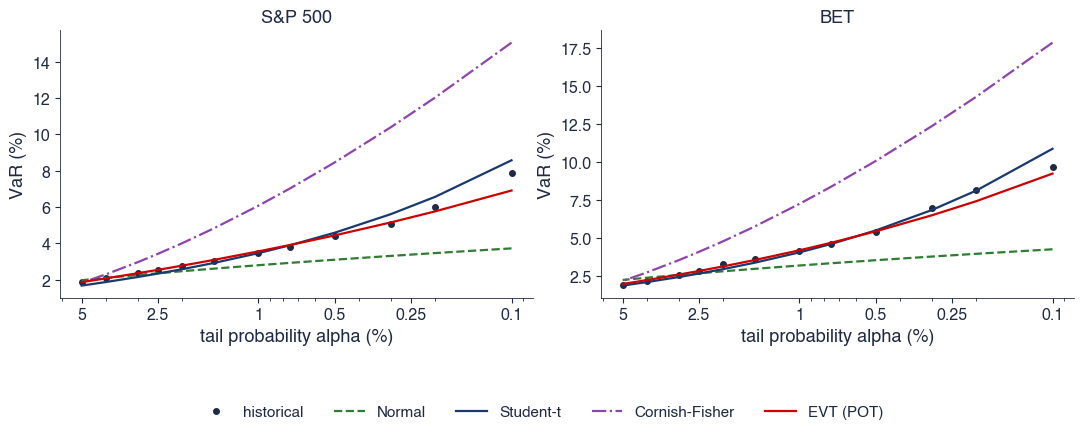

In [12]:
fig_var_curves(save=False)

In [13]:
precision()

{'all': {'n': 6714,
  'var': 3.455209453263386,
  'es': 3.7613189281197386,
  'var_lo': 3.17961377699838,
  'var_hi': 3.6580824553628766,
  'es_lo': 3.464217238515304,
  'es_hi': 4.0696184193475125,
  'var_se': 0.12143915463733934,
  'es_se': 0.15243589901554092},
 'last': {'n': 500,
  'var': 2.7485975645660687,
  'es': 2.9389510884292656,
  'var_lo': 1.9934615818868906,
  'var_hi': 4.960591283072979,
  'es_lo': 2.135370703899618,
  'es_hi': 3.8219682360258433,
  'var_se': 0.6198307320141029,
  'es_se': 0.44341456244003813}}

In [14]:
horizon_check()

{'var1': 3.455209453263386,
 'var_sqrt': 10.926331665257406,
 'var_h': 10.373889213216447,
 'h': 10,
 'var_n1': 2.7972101020826243,
 'var_nh': 8.676535369159563}

## 4. Rolling forecasts and backtests

- One-day VaR 1%, VaR 2.5% and ES 2.5% since 2005 (Bitcoin since 2017): HS and Normal on 500 days, GARCH-t and FHS re-estimated every 250 days.
- Kupiec, Christoffersen, the traffic light, the quantile loss and the Acerbi–Székely $Z_2$ test.

In [15]:
def rolling_forecasts(k, oos_start=None, window=WINDOW, refit=REFIT):
    """One-day-ahead VaR 1%, VaR 2.5% and ES 2.5% for every day from oos_start; the forecast for day t uses only data
    up to day t-1. HS and Normal: the last `window` returns. GARCH-t and FHS: GARCH(1,1)-t re-estimated every `refit`
    days on all data up to that day; FHS uses the empirical quantiles of the standardised residuals."""
    r = returns(k)
    x = r.values
    i0 = max(r.index.searchsorted(pd.Timestamp(oos_start or OOS_START[k])), window)
    W = np.lib.stride_tricks.sliding_window_view(x, window)[i0 - window:len(x) - window]    # windows ending at t-1
    Ws = np.sort(W, axis=1)
    k1 = int(np.ceil(window * ALPHA_VAR - 1e-9))
    k25 = int(np.ceil(window * ALPHA_ES - 1e-9))
    df = pd.DataFrame(index=r.index[i0:])
    df['r'] = x[i0:]
    df['var1_HS'] = -Ws[:, k1 - 1]
    df['var25_HS'] = -Ws[:, k25 - 1]
    df['es25_HS'] = -Ws[:, :k25].mean(axis=1)
    m, s = W.mean(axis=1), W.std(axis=1, ddof=1)
    df['mu_N'], df['sd_N'] = m, s
    df['var1_Normal'] = -(m + s * stats.norm.ppf(ALPHA_VAR))
    df['var25_Normal'] = -(m + s * stats.norm.ppf(ALPHA_ES))
    df['es25_Normal'] = -m + s * stats.norm.pdf(stats.norm.ppf(ALPHA_ES)) / ALPHA_ES
    cols = {c: [] for c in ['mu_G', 'sig_G', 'nu_G', 'block']}
    zs = []
    for b, s0 in enumerate(range(i0, len(r), refit)):
        e = min(s0 + refit, len(r))
        am = arch_model(r.iloc[:e], mean='Constant', vol='GARCH', p=1, q=1, dist='t')
        res = am.fit(disp='off', last_obs=r.index[s0], options={'maxiter': 2000})
        sig = am.fix(res.params).conditional_volatility.iloc[s0:e].values
        p = res.params
        cols['mu_G'] += [float(p['mu'])] * (e - s0)
        cols['sig_G'] += list(sig)
        cols['nu_G'] += [float(p['nu'])] * (e - s0)
        cols['block'] += [b] * (e - s0)
        zs.append(np.sort(res.std_resid.dropna().values))
    for c, v in cols.items():
        df[c] = v
    mu, sig, nu = df['mu_G'].values, df['sig_G'].values, df['nu_G'].values
    df['var1_GARCH-t'] = -(mu + sig * stats.t.ppf(ALPHA_VAR, nu) * np.sqrt((nu - 2) / nu))
    df['var25_GARCH-t'] = -(mu + sig * stats.t.ppf(ALPHA_ES, nu) * np.sqrt((nu - 2) / nu))
    qa = stats.t.ppf(ALPHA_ES, nu)
    df['es25_GARCH-t'] = -mu + sig * np.sqrt((nu - 2) / nu) * stats.t.pdf(qa, nu) * (nu + qa ** 2) / ((nu - 1) * ALPHA_ES)
    zq1 = np.array([-hs_var(z, ALPHA_VAR) for z in zs])[df['block'].values]
    zq25 = np.array([-hs_var(z, ALPHA_ES) for z in zs])[df['block'].values]
    zes = np.array([hs_es(z, ALPHA_ES) for z in zs])[df['block'].values]
    df['var1_FHS'] = -(mu + sig * zq1)
    df['var25_FHS'] = -(mu + sig * zq25)
    df['es25_FHS'] = -mu + sig * zes
    df.attrs['W'] = W
    df.attrs['zs'] = zs
    return df


def kupiec(x, n, a=ALPHA_VAR):
    """Kupiec (1995) proportion-of-failures test: LR_uc = -2 ln[(1-a)^(n-x) a^x / ((1-x/n)^(n-x) (x/n)^x)] ~ chi2(1)."""
    ph = x / n
    l0 = (n - x) * np.log(1 - a) + x * np.log(a)
    l1 = (n - x) * np.log(1 - ph) if ph < 1 else 0.0
    l1 += x * np.log(ph) if x > 0 else 0.0
    lr = float(-2 * (l0 - l1))
    return {'x': int(x), 'n': int(n), 'rate': float(ph), 'lr': lr, 'p': float(stats.chi2.sf(lr, 1))}


def christoffersen(hits, a=ALPHA_VAR):
    """Christoffersen (1998): independence LR_ind ~ chi2(1) from the transition counts n_ij (i = yesterday,
    j = today), and conditional coverage LR_cc = LR_uc + LR_ind ~ chi2(2)."""
    h = np.asarray(hits, int)
    h0, h1 = h[:-1], h[1:]
    n00 = int(np.sum((h0 == 0) & (h1 == 0)))
    n01 = int(np.sum((h0 == 0) & (h1 == 1)))
    n10 = int(np.sum((h0 == 1) & (h1 == 0)))
    n11 = int(np.sum((h0 == 1) & (h1 == 1)))
    p01 = n01 / (n00 + n01) if n00 + n01 else 0.0
    p11 = n11 / (n10 + n11) if n10 + n11 else 0.0
    p = (n01 + n11) / (n00 + n01 + n10 + n11)

    def ll(q, a_, b_):
        return (a_ * np.log(1 - q) if a_ and q < 1 else 0.0) + (b_ * np.log(q) if b_ and q > 0 else 0.0)
    lr_ind = float(-2 * (ll(p, n00 + n10, n01 + n11) - ll(p01, n00, n01) - ll(p11, n10, n11)))
    uc = kupiec(int(h.sum()), len(h), a)
    lr_cc = uc['lr'] + lr_ind
    return {'n00': n00, 'n01': n01, 'n10': n10, 'n11': n11, 'p01': float(p01), 'p11': float(p11),
            'lr_ind': lr_ind, 'p_ind': float(stats.chi2.sf(lr_ind, 1)), 'lr_cc': float(lr_cc),
            'p_cc': float(stats.chi2.sf(lr_cc, 2)), 'uc': uc}


def basel_zone(x):
    """Basel traffic light for 250 days at VaR 1%: green 0-4, yellow 5-9, red 10 or more exceptions."""
    return 'green' if x <= 4 else ('yellow' if x <= 9 else 'red')


def traffic_table(n=250, a=ALPHA_VAR, xmax=10):
    """Binomial(n, a) probability and cumulative probability of x exceptions, zone and plus factor (BCBS, 1996)."""
    return [{'x': x, 'p': float(stats.binom.pmf(x, n, a)), 'cum': float(stats.binom.cdf(x, n, a)), 'zone': basel_zone(x),
             'plus': PLUS.get(x, 1.0)} for x in range(xmax + 1)]


def z2_stat(r, var25, es25, a=ALPHA_ES):
    """Acerbi-Szekely (2014) Z2 = sum_t r_t I_t / (T a ES_t) + 1, I_t = 1{r_t < -VaR_t}; E[Z2] = 0 under the null,
    negative values: ES too small."""
    r, var25, es25 = (np.asarray(v, float) for v in (r, var25, es25))
    I = r < -var25
    return float(np.sum(r * I / es25) / (len(r) * a) + 1)


def z2_pvalue(df, m, nsim=N_Z2, seed=SEED):
    """p-value of Z2 by simulation: returns are drawn from each day's forecast distribution of method m and Z2 is
    recomputed with the same VaR and ES forecasts; p = share of simulated Z2 below the observed one."""
    rng = np.random.default_rng(seed)
    n = len(df)
    if m == 'Normal':
        X = df['mu_N'].values[:, None] + df['sd_N'].values[:, None] * rng.standard_normal((n, nsim))
    elif m == 'HS':
        W = df.attrs['W']
        X = W[np.arange(n)[:, None], rng.integers(0, W.shape[1], (n, nsim))]
    elif m == 'GARCH-t':
        nu = df['nu_G'].values[:, None]
        z = rng.standard_t(nu, (n, nsim)) * np.sqrt((nu - 2) / nu)
        X = df['mu_G'].values[:, None] + df['sig_G'].values[:, None] * z
    else:
        zs = df.attrs['zs']
        Z = np.empty((n, nsim))
        blk = df['block'].values
        for b, z in enumerate(zs):
            rows = np.where(blk == b)[0]
            Z[rows] = z[rng.integers(0, len(z), (len(rows), nsim))]
        X = df['mu_G'].values[:, None] + df['sig_G'].values[:, None] * Z
    v = df[f'var25_{m}'].values[:, None]
    e = df[f'es25_{m}'].values[:, None]
    zsim = np.sum(X * (X < -v) / e, axis=0) / (n * ALPHA_ES) + 1
    z0 = z2_stat(df['r'], df[f'var25_{m}'], df[f'es25_{m}'])
    return z0, float(np.mean(zsim <= z0))


def quantile_loss(r, var, a=ALPHA_VAR):
    """Average quantile (pinball) loss of VaR forecasts: S(v, x) = (a - 1{x < -v})(x + v); smaller is better."""
    r, var = np.asarray(r, float), np.asarray(var, float)
    return float(np.mean((a - (r < -var)) * (r + var)))


def backtest(df, m):
    """All backtests of method m on a frame of rolling forecasts."""
    hits = (df['r'] < -df[f'var1_{m}']).astype(int).values
    c = christoffersen(hits)
    last = hits[-250:].sum()
    z2, pz2 = z2_pvalue(df, m)
    return {'n': int(len(hits)), 'x': int(hits.sum()), 'rate': float(hits.mean()), 'exp': float(ALPHA_VAR * len(hits)),
            'lr_uc': c['uc']['lr'], 'p_uc': c['uc']['p'], 'lr_ind': c['lr_ind'], 'p_ind': c['p_ind'], 'lr_cc': c['lr_cc'],
            'p_cc': c['p_cc'], 'n11': c['n11'], 'n01': c['n01'], 'n10': c['n10'], 'n00': c['n00'], 'p01': c['p01'],
            'p11': c['p11'], 'last250': int(last), 'zone_last': basel_zone(last), 'z2': z2, 'p_z2': pz2,
            'zones': {z: int(np.sum([basel_zone(v) == z for v in pd.Series(hits).rolling(250).sum().dropna().values]))
                      for z in ('green', 'yellow', 'red')},
            'n_windows': int(len(hits) - 249), 'qloss': quantile_loss(df['r'], df[f'var1_{m}']),
            'max250': int(pd.Series(hits).rolling(250).sum().max())}


def stress_counts(df, m):
    """Exceedances of VaR 1% in the 2008 and 2020 stress periods."""
    out = {}
    for e, (a, b) in EPISODES.items():
        d = df.loc[a:b]
        out[e] = {'n': int(len(d)), 'x': int((d['r'] < -d[f'var1_{m}']).sum()), 'exp': float(ALPHA_VAR * len(d))}
    return out


def backtest_all(assets=BT_ASSETS):
    frames, res = {}, {}
    for k in assets:
        df = rolling_forecasts(k)
        frames[k] = df
        res[k] = {'start': df.index[0].date().isoformat(), 'end': df.index[-1].date().isoformat()}
        for m in METHODS:
            res[k][m] = backtest(df, m)
            res[k][m]['stress'] = stress_counts(df, m)
            res[k][m]['mean_var'] = float(df[f'var1_{m}'].mean())
    return res, frames

In [16]:
bt, frames = backtest_all()
pd.DataFrame({(NAME[k], m): {c: bt[k][m][c] for c in ['n', 'x', 'rate', 'p_uc', 'p_ind', 'p_cc', 'max250', 'qloss', 'z2', 'p_z2']} for k in BT_ASSETS for m in METHODS}).T.round(4)

n      x    rate    p_uc   p_ind    p_cc  max250  \
S&P 500 HS       5460.0   77.0  0.0141  0.0041  0.0000  0.0000    18.0   
        Normal   5460.0  148.0  0.0271  0.0000  0.0000  0.0000    29.0   
        GARCH-t  5460.0   95.0  0.0174  0.0000  0.1142  0.0000    10.0   
        FHS      5460.0   86.0  0.0158  0.0001  0.0599  0.0001    10.0   
DAX     HS       5517.0   67.0  0.0121  0.1215  0.0001  0.0002    12.0   
        Normal   5517.0  133.0  0.0241  0.0000  0.0000  0.0000    19.0   
        GARCH-t  5517.0   84.0  0.0152  0.0003  0.5492  0.0012     9.0   
        FHS      5517.0   77.0  0.0140  0.0053  0.4179  0.0148     9.0   
BET     HS       5432.0   66.0  0.0122  0.1234  0.0012  0.0016    14.0   
        Normal   5432.0  122.0  0.0225  0.0000  0.0000  0.0000    21.0   
        GARCH-t  5432.0   65.0  0.0120  0.1578  0.8071  0.3579     9.0   
        FHS      5432.0   65.0  0.0120  0.1578  0.2401  0.1849     7.0   
Bitcoin HS       3548.0   33.0  0.0093  0.6720  0.3160  0.5530     6.0   
        Normal   3548.0   69.0  0.0194  0.0000  0.0566  0.0000    16.0   
        GARCH-t  3548.0   48.0  0.0135  0.0450  0.6825  0.1233     8.0   
        FHS      3548.0   24.0  0.0068  0.0396  0.1552  0.0439     6.0   

                  qloss      z2   p_z2  
S&P 500 HS       0.0517 -0.3917  0.000  
        Normal   0.0580 -1.1481  0.000  
        GARCH-t  0.0371 -0.5397  0.000  
        FHS      0.0368 -0.2043  0.013  
DAX     HS       0.0515 -0.2589  0.002  
        Normal   0.0552 -0.8720  0.000  
        GARCH-t  0.0408 -0.4941  0.000  
        FHS      0.0405 -0.1846  0.014  
BET     HS       0.0604 -0.2660  0.001  
        Normal   0.0626 -0.8260  0.000  
        GARCH-t  0.0459 -0.2162  0.007  
        FHS      0.0462 -0.1766  0.021  
Bitcoin HS       0.1357 -0.0697  0.224  
        Normal   0.1452 -0.5642  0.000  
        GARCH-t  0.1353 -0.4050  0.000  
        FHS      0.1375  0.1188  0.834

In [17]:
pd.DataFrame({(NAME[k], m): {e: bt[k][m]['stress'][e]['x'] for e in EPISODES} for k in ['sp500', 'dax', 'bet'] for m in METHODS}).T

2008  2020
S&P 500 HS         15     9
        Normal     21    12
        GARCH-t     5     3
        FHS         5     3
DAX     HS          6     8
        Normal     18    13
        GARCH-t     3     3
        FHS         3     3
BET     HS          8     5
        Normal     14    10
        GARCH-t     4     4
        FHS         4     4

## 5. Charts of the backtests

- VaR 1% in 2008 and 2020; exceedance dates; Binomial(250, 1%) and the zones; the traffic light through time.

In [18]:
def fig_rolling_var(df, k='sp500', save=True):
    """Daily returns and minus VaR 1% of the four methods in the 2008 and 2020 stress periods."""
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
    for ax, (a, b) in zip(axes, [('2007-06-01', '2009-12-31'), ('2019-10-01', '2021-03-31')]):
        d = df.loc[a:b]
        ax.plot(d.index, d['r'], color=st.Teal, lw=0.6, alpha=0.7, label='daily return (%)')
        for m in METHODS:
            ax.plot(d.index, -d[f'var1_{m}'], color=MCOL[m], lw=1.5, ls='--' if m in ('HS', 'Normal') else '-',
                    label=f'minus VaR 1%, {m}')
        hit = d['r'] < -d['var1_HS']
        ax.scatter(d.index[hit], d['r'][hit], color=MCOL['HS'], s=22, zorder=5, label='exceedance of the HS VaR')
        ax.set_ylabel('%')
        ax.tick_params(axis='x', labelrotation=30)
    axes[0].set_title(f'{NAME[k]}, 2007-2009')
    axes[1].set_title(f'{NAME[k]}, 2019-2021')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.11, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch10_rolling_var')


def fig_hits(df, k='sp500', save=True):
    """Exceedance dates of the VaR 1% of each method: clusters show a lack of independence."""
    fig, ax = plt.subplots(figsize=(11, 3.6))
    for e, (a, b) in EPISODES.items():
        ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=st.Amber, alpha=0.15, label='_')
    for i, m in enumerate(METHODS):
        hit = df.index[df['r'] < -df[f'var1_{m}']]
        ax.scatter(hit, np.full(len(hit), i), color=MCOL[m], marker='|', s=180, lw=1.6,
                   label=f'{m}: {len(hit)} exceedances')
    ax.set_yticks(range(len(METHODS)))
    ax.set_yticklabels(METHODS)
    ax.set_ylim(-0.6, len(METHODS) - 0.4)
    ax.set_xlabel('date (shaded: September 2008 - March 2009 and February - May 2020)')
    st.legend_outside_bottom(ax, ncol=4, y=-0.32)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch10_hits')


def fig_binomial(n=250, a=ALPHA_VAR, save=True):
    """Binomial(250, 1%) distribution of the number of exceptions and the Basel zones."""
    tt = traffic_table(n, a, 14)
    fig, ax = plt.subplots(figsize=(10, 3.8))
    col = {'green': st.Forest, 'yellow': st.Amber, 'red': st.IDAred}
    lab = {'green': 'green zone (0-4)', 'yellow': 'yellow zone (5-9)', 'red': 'red zone (10 or more)'}
    seen = set()
    for row in tt:
        z = row['zone']
        ax.bar(row['x'], 100 * row['p'], color=col[z], label=lab[z] if z not in seen else '_')
        seen.add(z)
        if row['x'] <= 9:
            ax.text(row['x'], 100 * row['p'] + 0.6, f"{100 * row['cum']:.2f}", ha='center', fontsize=9, color=st.DarkText)
    ax.set_xlabel('number of exceptions in 250 days (labels: cumulative probability, %)')
    ax.set_ylabel('probability (%)')
    ax.set_xticks(range(0, 15))
    st.legend_outside_bottom(ax, ncol=3, y=-0.25)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch10_binomial')
    return tt


def fig_traffic_time(df, k='sp500', save=True):
    """Number of exceptions in the last 250 days for HS and GARCH-t, with the zone limits."""
    fig, ax = plt.subplots(figsize=(11, 3.8))
    for m in ('HS', 'Normal', 'GARCH-t'):
        c = (df['r'] < -df[f'var1_{m}']).astype(int).rolling(250).sum()
        ax.plot(c.index, c, color=MCOL[m], lw=1.5, label=f'{m}')
    ax.axhline(4.5, color=st.Forest, ls='--', lw=1.2, label='upper limit of the green zone (4)')
    ax.axhline(9.5, color=st.IDAred, ls='--', lw=1.2, label='upper limit of the yellow zone (9)')
    ax.set_ylabel('exceptions in 250 days')
    st.legend_outside_bottom(ax, ncol=3, y=-0.18)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch10_traffic_time')

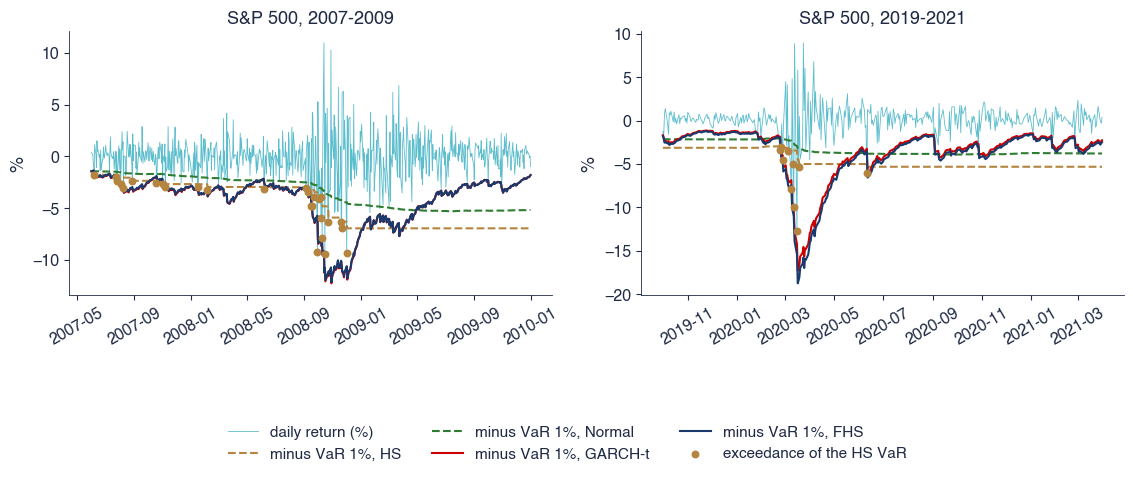

In [19]:
fig_rolling_var(frames['sp500'], save=False)

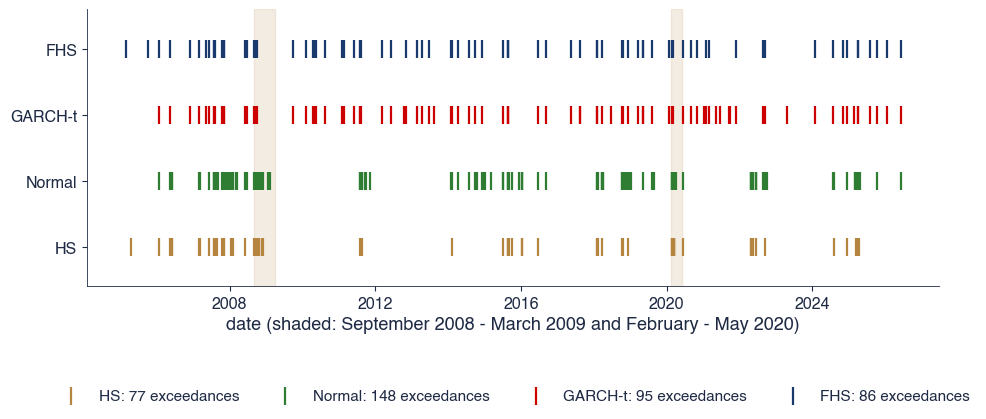

In [20]:
fig_hits(frames['sp500'], save=False)

,x,p,cum,zone,plus
0,0,8.105852e-02,0.081059,green,0.00
1,1,2.046932e-01,0.285752,green,0.00
2,2,2.574172e-01,0.543169,green,0.00
3,3,2.149477e-01,0.758117,green,0.00
4,4,1.340709e-01,0.892188,green,0.00
5,5,6.662919e-02,0.958817,yellow,0.40
6,6,2.748174e-02,0.986299,yellow,0.50
7,7,9.676109e-03,0.995975,yellow,0.65
8,8,2.968806e-03,0.998943,yellow,0.75
9,9,8.063424e-04,0.999750,yellow,0.85


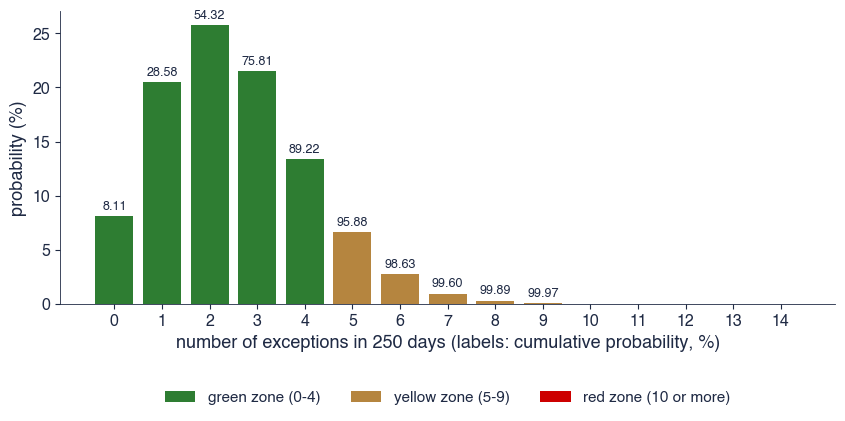

In [21]:
pd.DataFrame(fig_binomial(save=False))

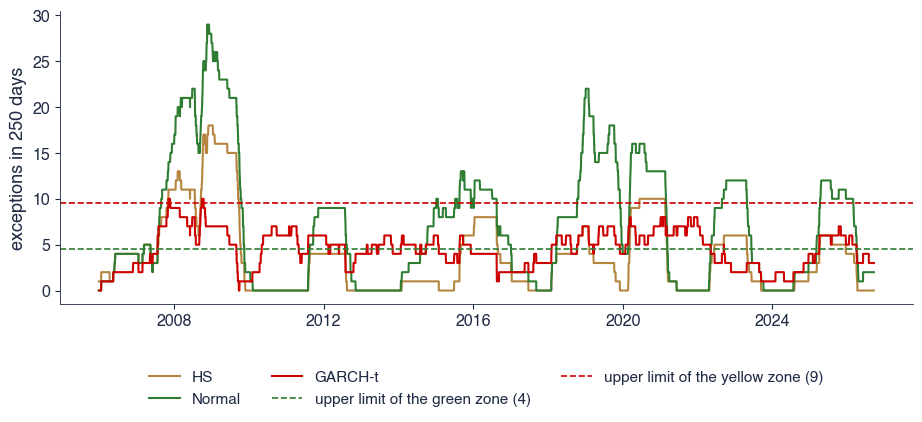

In [22]:
fig_traffic_time(frames['sp500'], save=False)

## 6. Portfolio VaR, tail dependence and copulas

- A 50/50 BET and S&P 500 portfolio: variance–covariance, historical simulation, Gaussian and t copulas with empirical margins.

In [23]:
def portfolio_data(keys=PORT):
    """Prices joined on common days first, then simple returns in % (the portfolio return is linear in them)."""
    P = pd.concat([load_close(k, START.get(k)) for k in keys], axis=1).dropna()
    R = 100 * P.pct_change().dropna()
    R.columns = list(keys)
    return R


def pseudo_obs(R):
    """Ranks divided by n + 1: the empirical copula sample (uniform margins)."""
    return R.rank().values / (len(R) + 1)


def t_copula_loglik(U, rho, nu):
    """Log-likelihood of the bivariate t copula with correlation rho and nu degrees of freedom."""
    x = stats.t.ppf(U, nu)
    q = (x[:, 0] ** 2 - 2 * rho * x[:, 0] * x[:, 1] + x[:, 1] ** 2) / (1 - rho ** 2)
    from scipy.special import gammaln
    lj = (gammaln((nu + 2) / 2) - gammaln(nu / 2) - np.log(nu * np.pi) - 0.5 * np.log(1 - rho ** 2)
          - (nu + 2) / 2 * np.log1p(q / nu))
    return float(np.sum(lj - stats.t.logpdf(x[:, 0], nu) - stats.t.logpdf(x[:, 1], nu)))


def gauss_copula_loglik(U, rho):
    x = stats.norm.ppf(U)
    q = (rho ** 2 * (x[:, 0] ** 2 + x[:, 1] ** 2) - 2 * rho * x[:, 0] * x[:, 1]) / (1 - rho ** 2)
    return float(np.sum(-0.5 * np.log(1 - rho ** 2) - 0.5 * q))


def t_tail_dependence(rho, nu):
    """lambda = 2 t_{nu+1}(-sqrt((nu + 1)(1 - rho)/(1 + rho))); the Gaussian copula has lambda = 0."""
    return float(2 * stats.t.cdf(-np.sqrt((nu + 1) * (1 - rho) / (1 + rho)), nu + 1))


def copula_fit(R):
    """rho from Kendall's tau (rho = sin(pi tau / 2)); nu of the t copula by maximum likelihood over a grid."""
    U = pseudo_obs(R)
    tau = float(stats.kendalltau(R.iloc[:, 0], R.iloc[:, 1])[0])
    rho = float(np.sin(np.pi * tau / 2))
    grid = np.arange(2.0, 40.01, 0.25)
    ll = np.array([t_copula_loglik(U, rho, v) for v in grid])
    nu = float(grid[np.argmax(ll)])
    return {'tau': tau, 'rho': rho, 'nu': nu, 'll_t': float(ll.max()), 'll_g': gauss_copula_loglik(U, rho),
            'lambda_t': t_tail_dependence(rho, nu), 'pearson': float(R.corr().iloc[0, 1]),
            'spearman': float(stats.spearmanr(R.iloc[:, 0], R.iloc[:, 1])[0])}


def empirical_tail_dep(R, qs=(0.05, 0.01)):
    """P(U1 <= q | U2 <= q): the share of the worst q of days of asset 2 that are also among the worst q of asset 1;
    under independence it equals q."""
    U = pseudo_obs(R)
    return {f'{q:g}': float(np.mean((U[:, 0] <= q) & (U[:, 1] <= q)) / q) for q in qs}


def simulate_copula(rho, nu=None, n=N_SIM, seed=SEED):
    """Uniform pairs from the Gaussian copula (nu None) or the t copula with correlation rho."""
    rng = np.random.default_rng(seed)
    Z = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], n)
    if nu is None:
        return stats.norm.cdf(Z)
    w = np.sqrt(nu / rng.chisquare(nu, n))
    return stats.t.cdf(Z * w[:, None], nu)


def portfolio_analysis(R=None, w=WEIGHTS):
    """Portfolio VaR 1% and ES 2.5%: variance-covariance (Normal), historical simulation, and copula simulation with
    empirical margins (Gaussian and t copula); tail dependence."""
    R = portfolio_data() if R is None else R
    w = np.asarray(w)
    mu, S = R.mean().values, R.cov().values
    sd = np.sqrt(np.diag(S))
    rp = R.values @ w
    mp, sp = float(w @ mu), float(np.sqrt(w @ S @ w))
    cf = copula_fit(R)
    out = {'n': int(len(R)), 'first': R.index[0].date().isoformat(), 'mu': mu.tolist(), 'sd': sd.tolist(),
           'corr': float(R.corr().iloc[0, 1]), 'mp': mp, 'sp': sp,
           'var_n': normal_var(mp, sp), 'es_n': normal_es(mp, sp),
           'var_n_single': [normal_var(mu[i], sd[i]) for i in range(2)],
           'var_hs': hs_var(rp), 'es_hs': hs_es(rp), 'var_hs_single': [hs_var(R.values[:, i]) for i in range(2)],
           'copula': cf, 'tail_emp': empirical_tail_dep(R)}
    out['var_n_sum'] = float(w @ np.array(out['var_n_single']))
    out['var_hs_sum'] = float(w @ np.array(out['var_hs_single']))
    out['contrib'] = (w * (S @ w) / sp).tolist()               # Euler contributions to sigma_p
    for lab, nu in [('gauss', None), ('t', cf['nu'])]:
        U = simulate_copula(cf['rho'], nu)
        X = np.column_stack([np.quantile(R.values[:, i], U[:, i]) for i in range(2)])
        xp = X @ w
        q1 = [np.quantile(R.values[:, i], 0.01) for i in range(2)]
        out[f'var_{lab}'] = hs_var(xp)
        out[f'es_{lab}'] = hs_es(xp)
        out[f'joint1_{lab}'] = float(np.mean((X[:, 0] <= q1[0]) & (X[:, 1] <= q1[1])))
    q1 = [np.quantile(R.values[:, i], 0.01) for i in range(2)]
    out['joint1_emp'] = float(np.mean((R.values[:, 0] <= q1[0]) & (R.values[:, 1] <= q1[1])))
    out['joint1_ind'] = 0.0001
    for e, (a, b) in EPISODES.items():
        out[f'corr_{e}'] = float(R.loc[a:b].corr().iloc[0, 1])
    out['corr_calm'] = float(R.loc['2017-01-01':'2017-12-31'].corr().iloc[0, 1])
    return out


def fig_rolling_corr(R=None, save=True):
    """250-day rolling correlation of BET and S&P 500 daily returns (common days)."""
    R = portfolio_data() if R is None else R
    c = R.iloc[:, 0].rolling(250).corr(R.iloc[:, 1]).dropna()
    fig, ax = plt.subplots(figsize=(11, 3.6))
    for e, (a, b) in EPISODES.items():
        ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=st.Amber, alpha=0.18, label='_')
    ax.plot(c.index, c, color=st.IDAred, lw=1.4, label='250-day correlation, BET and S&P 500')
    ax.axhline(R.corr().iloc[0, 1], color=st.MainBlue, ls='--', lw=1.2, label=f'whole sample: {R.corr().iloc[0, 1]:.2f}')
    ax.set_ylabel('correlation')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch10_rolling_corr')
    return {'max': float(c.max()), 'date_max': c.idxmax().date().isoformat(), 'min': float(c.min()),
            'last': float(c.iloc[-1])}


def fig_copula(R=None, fit=None, save=True):
    """Lower-left corner [0, 0.25]^2 of the pseudo-observations of BET and S&P 500 against samples of the same size from
    the fitted Gaussian and t copulas; the square marks the days on which both are among their worst 5%."""
    R = portfolio_data() if R is None else R
    cf = copula_fit(R) if fit is None else fit
    U = pseudo_obs(R)
    n = len(U)
    G = simulate_copula(cf['rho'], None, n, SEED + 1)
    Tt = simulate_copula(cf['rho'], cf['nu'], n, SEED + 2)
    fig, axes = plt.subplots(1, 3, figsize=(11.5, 4.0), sharey=True)
    q = 0.05
    for ax, (lab, X, c) in zip(axes, [('data (pseudo-observations)', U, st.MainBlue),
                                       (f'Gaussian copula, rho = {cf["rho"]:.2f}', G, st.Forest),
                                       (f't copula, rho = {cf["rho"]:.2f}, nu = {cf["nu"]:.1f}', Tt, st.IDAred)]):
        ax.scatter(X[:, 1], X[:, 0], s=7, color=c, alpha=0.6, label=lab)
        k = int(np.sum((X[:, 0] <= q) & (X[:, 1] <= q)))
        ax.plot([0, q, q], [q, q, 0], color=st.Orange, lw=2.0)
        ax.set_title(f'{k} pairs below 0.05 on both scales', fontsize=11)
        ax.set_xlabel('S&P 500 (uniform scale)')
        ax.set_xlim(0, 0.25)
        ax.set_ylim(0, 0.25)
    axes[0].set_ylabel('BET (uniform scale)')
    leg = st.fig_legend_bottom(fig, ncol=3, y=0.0)
    for h in leg.legend_handles:
        h.set_sizes([30])
        h.set_alpha(1)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch10_copula')
    return {'corner_data': int(np.sum((U[:, 0] <= q) & (U[:, 1] <= q))),
            'corner_gauss': int(np.sum((G[:, 0] <= q) & (G[:, 1] <= q))),
            'corner_t': int(np.sum((Tt[:, 0] <= q) & (Tt[:, 1] <= q))), 'n': int(n), 'expected_ind': float(n * q * q)}

In [24]:
R = portfolio_data()
P = portfolio_analysis(R)
{k: v for k, v in P.items() if k != 'copula'}

{'n': 6466,
 'first': '2000-01-06',
 'mu': [0.07615187915339787, 0.03379606788250279],
 'sd': [1.4231210144722957, 1.2284020669905797],
 'corr': 0.21083123304338217,
 'mp': 0.05497397351795033,
 'sp': 1.0333659248934661,
 'var_n': 2.348994648964212,
 'es_n': 2.3608317710637903,
 'var_n_single': [3.2345226673670715, 2.823894469128407],
 'var_hs': 3.079676521968455,
 'es_hs': 3.3012523135495755,
 'var_hs_single': [4.021818609013028, 3.439308123958207],
 'tail_emp': {'0.05': 0.21651716671821836, '0.01': 0.18558614290133002},
 'var_n_sum': 3.029208568247739,
 'var_hs_sum': 3.7305633664856175,
 'contrib': [0.5791368535622102, 0.4542290713312558],
 'var_gauss': 2.749476162575167,
 'es_gauss': 2.926436539909862,
 'joint1_gauss': 0.000295,
 'var_t': 2.8135754799992894,
 'es_t': 3.0334224458523926,
 'joint1_t': 0.001275,
 'joint1_emp': 0.0018558614290133002,
 'joint1_ind': 0.0001,
 'corr_2008': 0.3733651746227253,
 'corr_2020': 0.7079408550130922,
 'corr_calm': 0.20161296805478063}

In [25]:
P['copula']

{'tau': 0.10028651266222342,
 'rho': 0.15687896132019208,
 'nu': 4.5,
 'll_t': 219.50802800001074,
 'll_g': 92.07918696062731,
 'lambda_t': 0.09648572638390888,
 'pearson': 0.21083123304338217,
 'spearman': 0.14612847725774533}

{'max': 0.6700010062567588,
 'date_max': '2020-03-25',
 'min': -0.10031416408668146,
 'last': 0.12294075009622678}

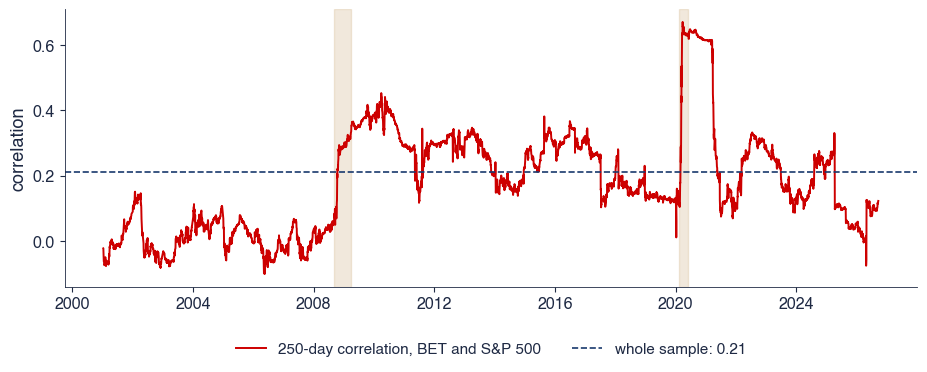

In [26]:
fig_rolling_corr(R, save=False)

{'corner_data': 70,
 'corner_gauss': 37,
 'corner_t': 55,
 'n': 6466,
 'expected_ind': 16.165000000000003}

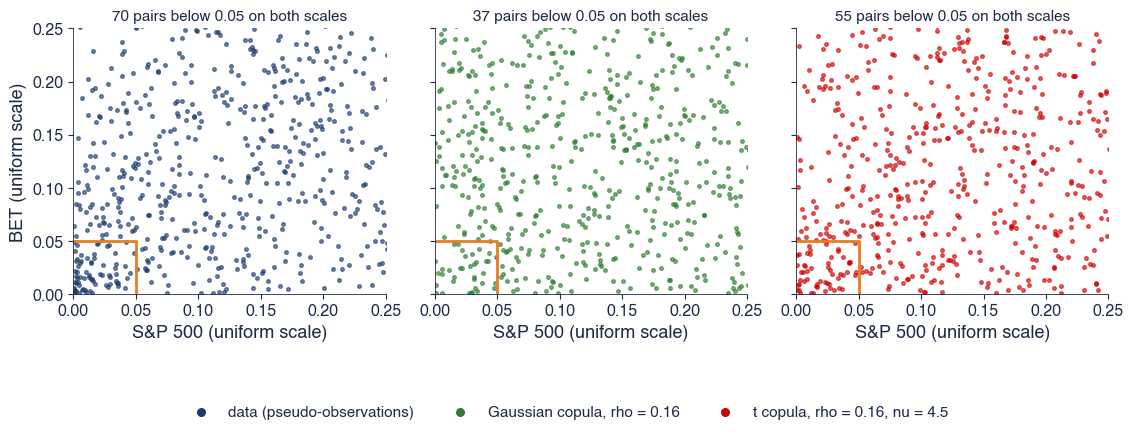

In [27]:
fig_copula(R, P['copula'], save=False)

## 7. AI for scientific discovery: does tail dependence jump in crises?

- Open question: does the tail dependence between the BVB and world markets rise in crises and come back?
- Starter result: the t copula fitted on separate calendar periods.
- Check before trusting any answer, yours or an AI's: the VaR convention (VaR 1% is a positive loss), prices joined on common days, pseudo-observations divided by $n + 1$, the uncertainty of tail estimates, overlapping windows.

In [28]:
for a, b in [('2005-01-01', '2007-12-31'), ('2008-01-01', '2009-12-31'), ('2017-01-01', '2019-12-31'), ('2020-01-01', '2021-12-31'), ('2023-01-01', '2026-09-18')]:
    cf = copula_fit(R.loc[a:b])
    print(a[:4], b[:4], 'rho', round(cf['rho'], 3), 'nu', cf['nu'], 'lambda', round(cf['lambda_t'], 3))

2005 2007 rho -0.002 nu 10.5 lambda 0.006
2008 2009 rho 0.313 nu 5.5 lambda 0.111


2017 2019 rho 0.168 nu 5.25 lambda 0.078
2020 2021 rho 0.24 nu 2.25 lambda 0.246


2023 2026 rho 0.164 nu 20.5 lambda 0.001
